[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/tour-de-france-clustering/blob/main/projet_03.ipynb)



# Dessiner le Tour de France : clustering et optimisation de tournées

Le problème : répartir 120 villages français en 21 étapes géographiquement cohérentes,
puis trouver dans chaque étape l'ordre de passage le plus court.

Le résultat : de 46 789 km (ordre alphabétique du fichier) à 4 063 km.
Une division par 11,5.

C'est un problème du voyageur de commerce, dont l'énumération exhaustive est impossible :
pour 120 villages, le nombre d'ordres possibles s'écrit avec 199 chiffres. La solution
combine un découpage par clustering et deux heuristiques d'optimisation.

La Partie 5 va au-delà de l'exercice : elle teste une correction du principal défaut du tracé,
mesure qu'elle échoue, et démontre chiffres à l'appui que le problème vient de la liste de
villages elle-même.

*Exercice issu du Cahier de Vacances Data de Machine Learnia (Guillaume Saint-Cirgue).
Le code, l'analyse et la Partie 5 sont les miens.*

### Les outils du jour : le clustering et les heuristiques

Ce projet est spécial : on va utiliser deux familles d'outils, et c'est leur combinaison qui fait la magie.

Premier outil : le clustering, la star de l'apprentissage non supervisé. On demande simplement à l'algorithme de découvrir tout seul des groupes naturels dans les données. C'est ça, le non supervisé, et c'est ce qui tourne derrière la segmentation de clients, la détection de communautés sur les réseaux sociaux ou l'organisation automatique de tes photos de vacances.

Deuxième outil : les heuristiques d'optimisation. Une fois les étapes créées, il faudra trouver le plus court chemin qui traverse chacune d'elles. Ce problème porte un nom célèbre : le problème du voyageur de commerce (Traveling Salesman Problem, TSP pour les intimes). Énoncé en 1930, étudié depuis par des générations de chercheurs, personne n'a jamais trouvé de méthode rapide qui garantisse la meilleure solution quand le nombre de villes grandit. On sait en revanche trouver de très bonnes solutions, très vite, avec des heuristiques : des stratégies astucieuses qui ne promettent pas la perfection, mais s'en approchent. Tournées de livreurs, ramassage scolaire, déplacement des têtes de perçage sur les circuits imprimés de ton ordinateur : le TSP est partout.

Au programme : explorer nos 120 villages, comparer deux algorithmes de clustering et justifier notre choix comme de vrais data scientists, puis tracer le parcours optimal de chaque étape avec un algorithme glouton et le fameux 2-opt. À la fin, tu imprimeras le livre de route officiel du Tour 2027, carte à l'appui.

# Avant tout : Import de nos librairies

Il y'a un fichier `utils.py` à côté du notebook : il contient la "plomberie" du projet, surtout les fonctions d'affichage des cartes (du `matplotlib` sans mystère, mais un peu long, avec notamment le contour de la France stocké point par point !). Le notebook reste ainsi concentré sur ce qui compte : les algorithmes.


In [3]:
import os

MANQUANTS = [f for f in ("utils.py", "villages_2027.csv") if not os.path.exists(f)]

if MANQUANTS:
    try:
        from google.colab import files  # Colab : téléverse les fichiers manquants
        print("Fichiers manquants :", ", ".join(MANQUANTS))
        files.upload()
    except ImportError:  # local : ils doivent être à côté du notebook
        raise FileNotFoundError(
            f"Fichiers absents : {MANQUANTS}. Place-les dans le dossier du notebook."
        )
else:
    print("Fichiers présents, on peut y aller.")

Fichiers présents, on peut y aller.


In [4]:
import math

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from utils import (
    load_villages,
    plot_villages,
    plot_stages,
    plot_stage_zoom,
    plot_final_tour,
    print_roadbook,
)

# Partie 1 : Les 120 villages du comité

Léa t'envoie le fichier officiel : `villages_2027.csv`. Il est déjà fourni dans le dossier du projet, et il contient les 120 villages sélectionnés, avec pour chacun :

| Colonne | Description |
|---|---|
| `village` | le nom du village |
| `departement` | le code de son département |
| `latitude` | sa position nord-sud sur le globe, en degrés |
| `longitude` | sa position est-ouest sur le globe, en degrés |

La latitude et la longitude, c'est l'adresse GPS d'un point sur Terre : deux nombres qui suffisent à localiser n'importe quel endroit du globe. Ce sont eux qui vont nous permettre de regrouper les villages, puis de calculer toutes les distances.

Chargeons le fichier :

In [5]:
villages = load_villages("villages_2027.csv")

print(f"{len(villages)} villages au programme du Tour 2027")
display(villages.head())

assert len(villages) == 120, f"Le fichier devrait contenir 120 villages, il y en a {len(villages)}"
assert list(villages.columns) == ["village", "departement", "latitude", "longitude"], "Colonnes inattendues"
print("Données chargées, on peut y aller !")

120 villages au programme du Tour 2027


,village,departement,latitude,longitude
0,Aiguèze,30,44.30342,4.55532
1,Angles-sur-l'Anglin,86,46.69547,0.88455
2,Ansouis,84,43.73754,5.46397
3,Apremont-sur-Allier,18,46.90640,3.04751
4,Arlempdes,43,44.86556,3.92273


Données chargées, on peut y aller !


### Étape 1 : quels départements sont les plus gâtés ?

Avant de découper quoi que ce soit, faisons connaissance avec nos villages. Première curiosité : le comité a-t-il favorisé certains départements ? Compte le nombre de villages par département et affiche le top 10.



,count
departement,
17,4
19,4
12,4
30,3
46,3
82,3
64,3
83,3
84,3


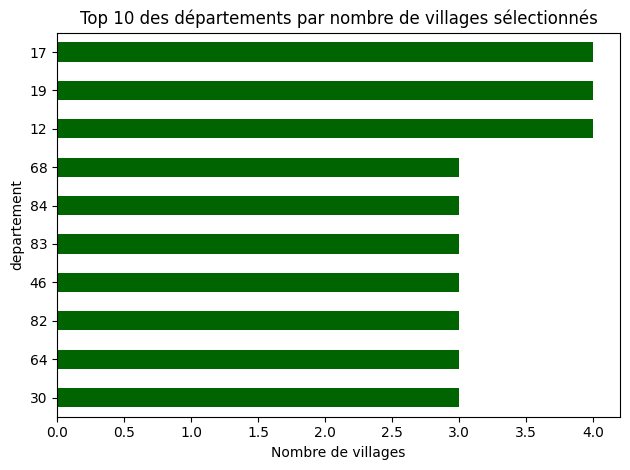

Exercice validé ! L'Aveyron, la Charente-Maritime et la Corrèze se partagent la tête.


In [6]:
### START CODE HERE ###
villages_per_dept = villages["departement"].value_counts().head(10)
### END CODE HERE ###

display(villages_per_dept)

villages_per_dept.sort_values().plot(kind="barh", color="darkgreen")
plt.title("Top 10 des départements par nombre de villages sélectionnés")
plt.xlabel("Nombre de villages")
plt.tight_layout()
plt.show()

assert len(villages_per_dept) == 10, f"Il faut un top 10, tu as {len(villages_per_dept)} lignes"
assert villages_per_dept.max() == 4, "Le maximum devrait être de 4 villages pour un même département"
print("Exercice validé ! L'Aveyron, la Charente-Maritime et la Corrèze se partagent la tête.")

### La carte des 120 villages

Un tableau de coordonnées ne parle à personne. Affichons plutôt nos villages sur une carte, avec la fonction `plot_villages` de `utils.py`. En fond, elle dessine le contour de la France métropolitaine (Corse comprise) pour situer chaque village d'un coup d'œil.

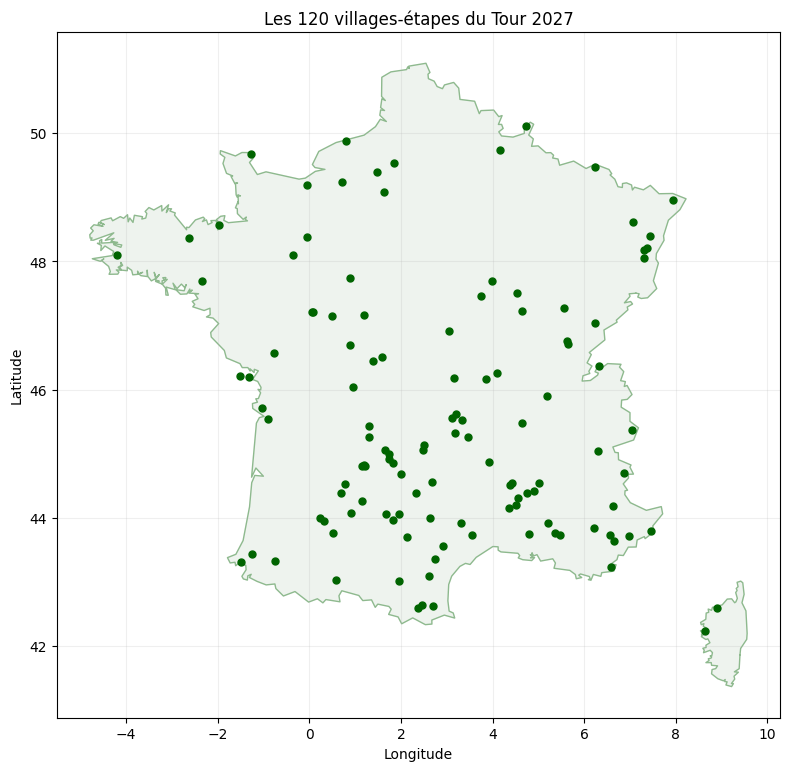

In [7]:
plot_villages(villages)

# Partie 2 : découper la France en 21 étapes

Le comité est formel : le Tour 2027 comptera 21 étapes, comme les vraies éditions. Il faut donc répartir nos 120 villages en 21 groupes, et pas n'importe comment : chaque étape doit rassembler des villages géographiquement proches, sinon les coureurs passeront leurs journées dans le bus.

Regarde la carte ci-dessus et essaie de dessiner mentalement 21 groupes... Pas évident, hein ? Là où ton œil hésite, un algorithme de clustering va trancher en quelques millisecondes. Le principe : on lui donne les positions des villages, et il forme tout seul des groupes de points proches les uns des autres. Aucune étiquette, aucune "bonne réponse" fournie : c'est de l'apprentissage non supervisé.

Et comme un bon data scientist ne se contente jamais du premier algorithme venu, on va en tester deux, comparer leurs résultats, et justifier notre choix. C'est exactement ce qu'on te demandera en entreprise : pas juste "j'ai fait un clustering", mais "j'ai comparé, et voilà pourquoi j'ai retenu celui-là".


### Convertir les degrés en kilomètres

Avant de lancer le moindre algorithme, un piège à déjouer. Les algorithmes de clustering raisonnent en distances : "ces deux points sont-ils proches ?". Or nos coordonnées sont en degrés, et sur une sphère, tous les degrés ne se valent pas : un degré de latitude vaut environ 111 km partout, mais un degré de longitude vaut 111 km à l'équateur et seulement 77 km à la latitude de la France (les méridiens se resserrent vers les pôles !).

Si on donne les degrés bruts à l'algorithme, il verra une France "étirée" d'est en ouest et formera des groupes déformés. La parade est simple : convertir les deux axes en kilomètres. On orée deux nouvelles colonnes :

- `y_km` : la latitude multipliée par 111
- `x_km` : la longitude multipliée par 111, multipliée par le cosinus de la latitude moyenne (convertie en radians)

In [8]:
lat_mean = villages["latitude"].mean()
print(f"Latitude moyenne de nos villages : {lat_mean:.2f}° (1 degré de longitude y vaut {111 * math.cos(math.radians(lat_mean)):.0f} km)")

villages["y_km"] = villages["latitude"] * 111
villages["x_km"] = villages["longitude"] * 111 * math.cos(math.radians(lat_mean))

display(villages.head())

assert "x_km" in villages.columns and "y_km" in villages.columns, "Il manque les colonnes x_km et y_km"
assert abs(villages["y_km"].iloc[0] - villages["latitude"].iloc[0] * 111) < 1e-6, "y_km doit valoir latitude x 111"
assert abs(villages["x_km"].iloc[0] - villages["longitude"].iloc[0] * 111 * math.cos(math.radians(lat_mean))) < 1e-6, \
    "x_km doit valoir longitude x 111 x cos(lat_mean en radians)"
assert 800 < villages["y_km"].max() - villages["y_km"].min() < 1000, \
    "Du village le plus au nord au plus au sud, il devrait y avoir environ 870 km"
print("Exercice validé ! Nos villages vivent maintenant dans un plan en kilomètres.")

Latitude moyenne de nos villages : 45.63° (1 degré de longitude y vaut 78 km)


,village,departement,latitude,longitude,y_km,x_km
0,Aiguèze,30,44.30342,4.55532,4917.67962,353.579258
1,Angles-sur-l'Anglin,86,46.69547,0.88455,5183.19717,68.657862
2,Ansouis,84,43.73754,5.46397,4854.86694,424.107737
3,Apremont-sur-Allier,18,46.90640,3.04751,5206.61040,236.544595
4,Arlempdes,43,44.86556,3.92273,4980.07716,304.478272


Exercice validé ! Nos villages vivent maintenant dans un plan en kilomètres.


### Premier candidat, le K-Means

Le K-Means est la star du clustering, et son idée tient sur un ticket de métro. On place 21 "centres" au hasard sur la carte, puis on répète deux gestes jusqu'à ce que plus rien ne bouge :

1. chaque village rejoint le centre le plus proche de lui
2. chaque centre se déplace au milieu des villages qui l'ont rejoint

C'est tout. Les centres migrent, les groupes se stabilisent, et on obtient un découpage où chaque village appartient au groupe dont le centre est le plus proche.


21 étapes créées, étiquettes de 0 à 20


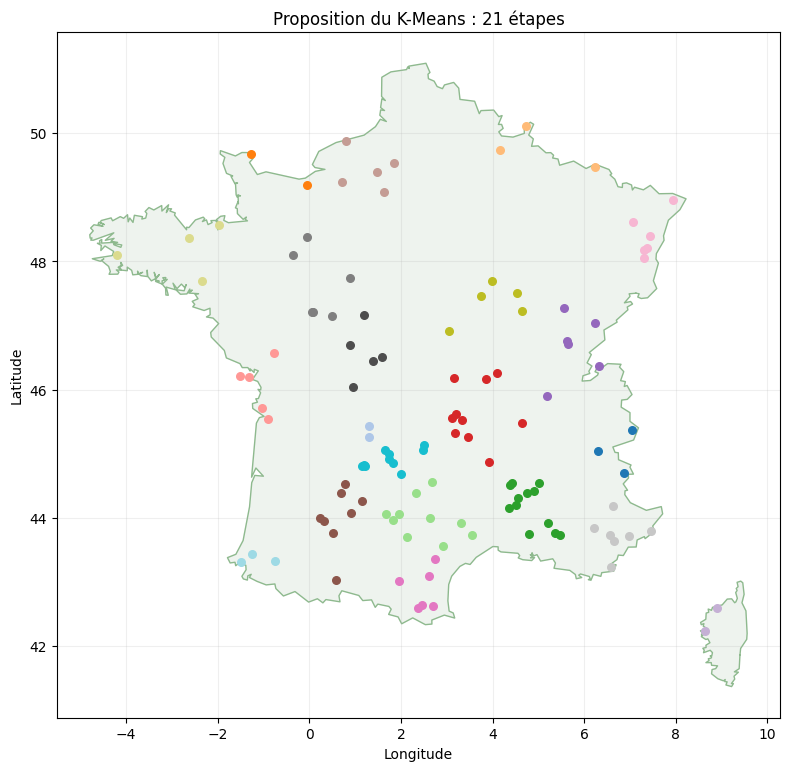

Exercice validé !


In [9]:
N_STAGES = 21

kmeans = KMeans(n_clusters=N_STAGES, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(villages[["x_km", "y_km"]])

print(f"{len(set(labels_kmeans))} étapes créées, étiquettes de {labels_kmeans.min()} à {labels_kmeans.max()}")
plot_stages(villages, labels_kmeans, title="Proposition du K-Means : 21 étapes")

assert len(labels_kmeans) == 120, "Il faut une étiquette par village"
assert len(set(labels_kmeans)) == 21, f"Il faut 21 étapes, tu en as {len(set(labels_kmeans))}"
print("Exercice validé !")

Avant de passer au challenger, une vérification qui va peser lourd dans le choix final :
la taille des groupes. La compacité ne fait pas tout une étape du Tour avec un seul
village n'a aucun sens sportif.

In [10]:
pd.Series(labels_kmeans).value_counts().sort_index()

,count
0,3
1,2
2,2
3,3
4,12
5,10
6,10
7,5
8,6
9,2


Pas mal, non ? Des groupes compacts, bien répartis sur le territoire. Mais ne nous emballons pas : un seul candidat, ce n'est pas un casting.

### Étape 4 : deuxième candidat, la CAH

Voici un challenger avec une philosophie complètement différente : la Classification Ascendante Hiérarchique (CAH, ou clustering agglomératif). Au départ, chaque village est seul dans son propre groupe : 120 groupes. Puis, à chaque tour, on fusionne les deux groupes les plus proches. 119 groupes, puis 118, puis 117... et on s'arrête pile quand il en reste 21.

Le critère de fusion qu'on utilise s'appelle `ward` : il choisit à chaque tour la fusion qui garde les groupes les plus compacts possible. C'est le réglage le plus courant, et un bon défaut.

À toi de jouer : crée un `AgglomerativeClustering` avec `n_clusters=N_STAGES` et `linkage="ward"`, puis récupère les étiquettes dans `labels_cah` avec `.fit_predict(...)` sur les mêmes colonnes. Remarque au passage qu'il n'y a pas de `random_state` : la CAH ne tire rien au hasard, elle donne toujours le même résultat.

> Indice : c'est exactement la même mécanique qu'à l'étape 3, en deux lignes.

21 étapes créées


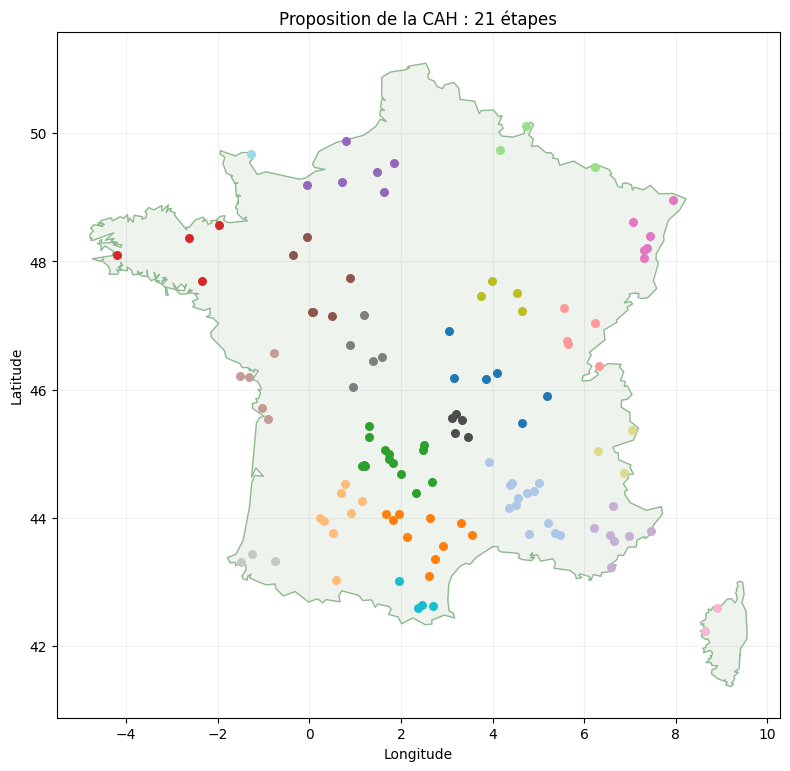

Exercice validé !


In [11]:
### START CODE HERE ###
cah = AgglomerativeClustering(n_clusters=N_STAGES, linkage="ward")
labels_cah = cah.fit_predict(villages[["x_km", "y_km"]])
### END CODE HERE ###

print(f"{len(set(labels_cah))} étapes créées")
plot_stages(villages, labels_cah, title="Proposition de la CAH : 21 étapes")

assert len(labels_cah) == 120, "Il faut une étiquette par village"
assert len(set(labels_cah)) == 21, f"Il faut 21 étapes, tu en as {len(set(labels_cah))}"
print("Exercice validé !")

Les deux découpages se ressemblent-ils vraiment ? Une table croisée le dit d'un coup d'œil :
chaque case compte les villages classés dans le groupe `i` par le K-Means et `j` par la CAH.
Des valeurs concentrées signalent un accord, des valeurs dispersées un désaccord.

In [12]:
pd.crosstab(labels_kmeans, labels_cah)

col_0,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
row_0,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,3,0,0,0
1,0,0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,12,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,8,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,4,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
7,0,0,0,0,0,0,0,0,0,0,...,5,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,5,0,0,...,0,0,0,0,0,0,0,0,0,0


### Étape 5 : le match K-Means contre CAH

Deux découpages, tous les deux plausibles à l'œil. Lequel présenter au comité ? C'est Le moment délicat du non supervisé : sans "bonne réponse", comment juger ?

On va combiner deux angles d'attaque, et c'est une leçon qui vaut bien au-delà de ce projet :

1. Une métrique : le score de silhouette. Pour chaque village, il compare sa distance moyenne aux villages de son groupe (cohésion) et sa distance au groupe voisin le plus proche (séparation). Le score final va de -1 (découpage absurde) à +1 (groupes parfaitement nets). C'est la note "qualité géométrique" du découpage.
2. Un regard métier : les tailles des étapes. Une étape du Tour avec un seul village, ça n'a aucun sens sportif, peu importe ce que dit la géométrie.

À toi de jouer :

1. Calcule `sil_kmeans` et `sil_cah` avec `silhouette_score(features, labels)`, où les features sont nos colonnes `x_km` et `y_km`
2. Calcule `sizes_kmeans` et `sizes_cah`, le nombre de villages par étape (transforme les étiquettes en Series avec `pd.Series(...)` puis utilise `.value_counts()`)

Silhouette K-Means : 0.461 | étapes de 2 à 12 villages
Silhouette CAH     : 0.467 | étapes de 1 à 14 villages


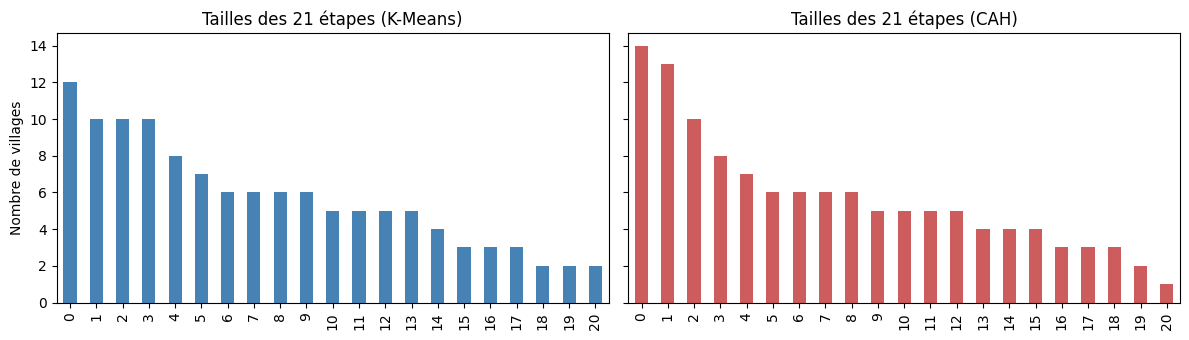

Exercice validé !


In [13]:
### START CODE HERE ###
features = villages[["x_km", "y_km"]]

sil_kmeans = silhouette_score(features, labels_kmeans)
sil_cah = silhouette_score(features, labels_cah)

sizes_kmeans = pd.Series(labels_kmeans).value_counts()
sizes_cah = pd.Series(labels_cah).value_counts()
### END CODE HERE ###

print(f"Silhouette K-Means : {sil_kmeans:.3f} | étapes de {sizes_kmeans.min()} à {sizes_kmeans.max()} villages")
print(f"Silhouette CAH     : {sil_cah:.3f} | étapes de {sizes_cah.min()} à {sizes_cah.max()} villages")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
sizes_kmeans.sort_values(ascending=False).reset_index(drop=True).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Tailles des 21 étapes (K-Means)")
axes[0].set_ylabel("Nombre de villages")
sizes_cah.sort_values(ascending=False).reset_index(drop=True).plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Tailles des 21 étapes (CAH)")
plt.tight_layout()
plt.show()

assert 0.30 < sil_kmeans < 0.60, f"La silhouette du K-Means devrait avoisiner 0.46, tu obtiens {sil_kmeans:.3f}"
assert 0.30 < sil_cah < 0.60, f"La silhouette de la CAH devrait avoisiner 0.47, tu obtiens {sil_cah:.3f}"
assert sizes_kmeans.sum() == 120 and sizes_cah.sum() == 120, "Chaque village doit appartenir à une étape"
print("Exercice validé !")

### Le verdict, et pourquoi la métrique perd

Les deux critères se contredisent, et c'est tout l'intérêt de l'étape.

| | Silhouette | Taille des étapes |
|---|---:|---|
| K-Means | 0,461 | 2 à 12 villages |
| **CAH** | **0,467** | 1 à 14 villages |

Sur la silhouette, la CAH gagne de six millièmes. Si l'on s'arrêtait à la métrique, on la
retiendrait sans hésiter.

Mais la CAH produit une étape à un seul village. Ce n'est pas une étape : c'est un village
isolé qu'aucun coureur ne peut « parcourir ». Aucun écart de silhouette ne rachète ça.

On retient donc le K-Means, moins bon sur le papier, utilisable dans la réalité.

C'est la leçon la plus transposable du projet, et elle vaut bien au-delà du clustering :
une métrique optimisée n'est pas un objectif atteint. La silhouette mesure la netteté
géométrique des groupes, pas leur utilité pour organiser une course cycliste. Elle ne connaît
pas la question métier c'est à l'analyste de la poser.

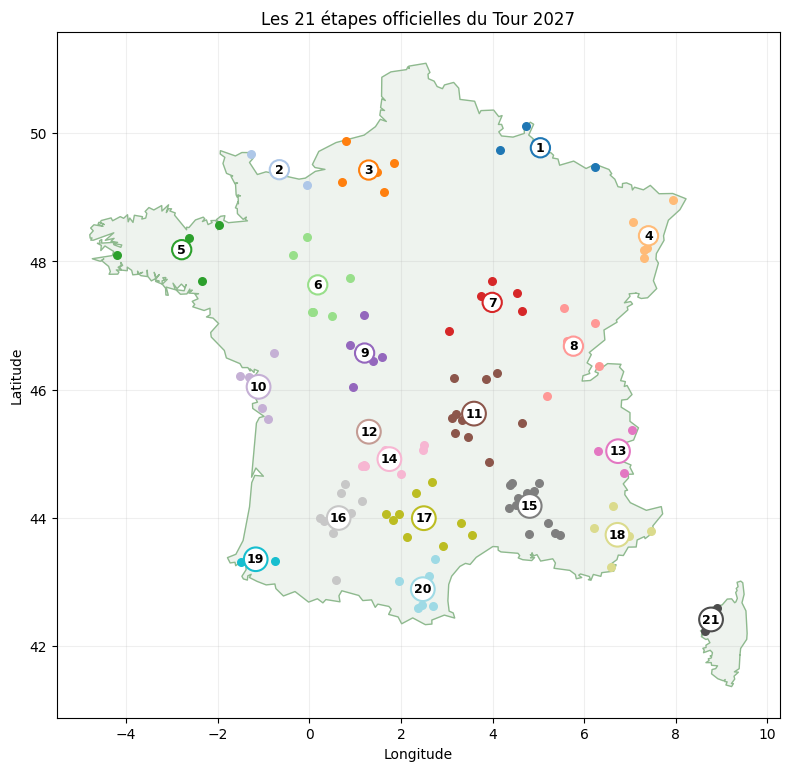

Mission 1 accomplie : la France est découpée en 21 étapes !


In [14]:
villages["stage"] = labels_kmeans

# on renumérote les étapes du nord au sud : plus lisible qu'une numérotation arbitraire
stage_order = villages.groupby("stage")["latitude"].mean().sort_values(ascending=False).index
villages["stage"] = villages["stage"].map({old: new + 1 for new, old in enumerate(stage_order)})

plot_stages(villages, villages["stage"], title="Les 21 étapes officielles du Tour 2027", numbered=True)

assert set(villages["stage"]) == set(range(1, 22)), "Les étapes doivent être numérotées de 1 à 21"
print("Mission 1 accomplie : la France est découpée en 21 étapes !")

In [15]:
print(f"K-Means : de {sizes_kmeans.min()} à {sizes_kmeans.max()} villages")
print(f"CAH : de {sizes_cah.min()} à {sizes_cah.max()} villages")

K-Means : de 2 à 12 villages
CAH : de 1 à 14 villages


# Partie 3 : Mission 2, le parcours de chaque étape

Tu envoies la carte à Léa. Réponse dans la minute : "Le comité ADORE. Maintenant, l'ordre de passage ! Chaque étape doit partir d'un village, traverser tous les autres, et s'arrêter au dernier. Le lendemain, les bus emmènent tout le monde au départ de l'étape suivante" (oui, ça se passe vraiment comme ça sur le vrai Tour, ça s'appelle un transfert).

Chaque étape est donc un chemin ouvert : un départ, une arrivée, et tous les villages de l'étape entre les deux. Reste à trouver, pour chacune des 21 étapes, l'ordre qui minimise les kilomètres. Bienvenue dans le problème du voyageur de commerce.

Mais avant d'optimiser quoi que ce soit, il faut savoir mesurer. Comment calculer la distance entre deux villages à partir de leurs coordonnées GPS ?

### Étape 6 : la distance entre deux villages

Tu vas me dire : on a déjà `x_km` et `y_km`, Pythagore et c'est réglé ! Pas faux, et pour la France l'approximation serait très correcte. Mais je veux te montrer la vraie formule, celle qui tourne dans ton GPS et qui reste exacte partout sur le globe : la formule de haversine, qui calcule la distance "à vol d'oiseau" sur une sphère.

Voici la recette, à traduire en Python dans la fonction ci-dessous :

1. Convertis les 4 coordonnées de degrés en radians avec `math.radians(...)`
2. Calcule les écarts : `delta_lat` (écart de latitude) et `delta_lon` (écart de longitude), en radians
3. Calcule le terme intermédiaire :
   `a = sin(delta_lat / 2)² + cos(lat1) × cos(lat2) × sin(delta_lon / 2)²`
4. La distance vaut : `2 × R × asin(√a)` avec `R = 6371` km (le rayon de la Terre)

> Indice : `math.sin`, `math.cos`, `math.asin` et `math.sqrt` sont tes amis, et `x ** 2` élève au carré.

In [17]:
def haversine(lat1, lon1, lat2, lon2):
    """Compute the great-circle distance between two GPS points, in kilometers.

    Arguments:
    lat1, lon1 : latitude and longitude of the first point, in degrees
    lat2, lon2 : latitude and longitude of the second point, in degrees

    Returns:
    distance : distance between the two points, in kilometers
    """
    earth_radius = 6371

    ### START CODE HERE ###
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1

    a = (math.sin(delta_lat / 2) ** 2
         + math.cos(lat1) * math.cos(lat2) * math.sin(delta_lon / 2) ** 2)

    distance = 2 * earth_radius * math.asin(math.sqrt(a))

    ### END CODE HERE ###

    return distance


paris_marseille = haversine(48.8566, 2.3522, 43.2965, 5.3698)
print(f"Paris  Marseille à vol d'oiseau : {paris_marseille:.0f} km")

assert 640 < paris_marseille < 680, f"Paris-Marseille devrait faire environ 660 km, tu obtiens {paris_marseille:.0f}"
assert abs(haversine(48.8566, 2.3522, 43.2965, 5.3698) - haversine(43.2965, 5.3698, 48.8566, 2.3522)) < 1e-9, \
    "La distance doit être la même dans les deux sens !"
assert haversine(45.0, 3.0, 45.0, 3.0) == 0, "La distance d'un point à lui-même doit être nulle"
print("Exercice validé !")

Paris  Marseille à vol d'oiseau : 660 km
Exercice validé !


### Étape 7 : la matrice des distances

Nos algorithmes vont comparer des distances des dizaines de milliers de fois. Plutôt que de recalculer la formule de haversine à chaque fois, on va tout précalculer une bonne fois pour toutes dans une matrice des distances : un tableau à deux dimensions où `distances[i][j]` donne la distance entre le village numéro `i` et le village numéro `j`.

On te prépare la liste `coords` des coordonnées. À toi de construire la matrice : une liste de listes, remplie avec une double boucle (ou une double compréhension de liste, comme tu préfères).

In [18]:
coords = list(zip(villages["latitude"], villages["longitude"]))
n_villages = len(coords)

### START CODE HERE ###
distances = [
    [haversine(lat1, lon1, lat2, lon2) for lat2, lon2 in coords]
    for lat1, lon1 in coords
]
### END CODE HERE ###

print(f"Matrice {len(distances)} x {len(distances[0])} calculée")
print(f"Distance entre {villages['village'][0]} et {villages['village'][1]} : {distances[0][1]:.0f} km")

assert len(distances) == 120 and len(distances[0]) == 120, "La matrice doit faire 120 x 120"
assert all(distances[i][i] == 0 for i in range(120)), "La diagonale doit être nulle (village vers lui-même)"
assert abs(distances[3][77] - distances[77][3]) < 1e-9, "La matrice doit être symétrique"
assert max(max(row) for row in distances) < 1300, "Aucune paire de villages français ne dépasse 1300 km"
print("Exercice validé !")

Matrice 120 x 120 calculée
Distance entre Aiguèze et Angles-sur-l'Anglin : 391 km
Exercice validé !


Trois propriétés doivent être vraies pour que la matrice soit correcte : ses dimensions,
une diagonale nulle (distance d'un village à lui-même), et la symétrie.

In [19]:
print(len(distances), len(distances[0])) # doit valoir n_villages × n_villages
print(distances[0][0]) # 0.0 : distance d'un village à lui-même
print(distances[3][7] == distances[7][3])  # True : la matrice est symétrique

120 120
0.0
True


### Étape 8 : mesurer un parcours d'étape

Un parcours, pour nous, c'est simplement une liste d'indices de villages dans l'ordre de passage : `[42, 17, 3, ...]`. Écris la fonction `path_distance` qui calcule la longueur totale d'un parcours.

Attention à la subtilité qui change tout par rapport à une boucle fermée : une étape a un départ et une arrivée, on ne revient PAS au village de départ. Il y a donc exactement `len(path) - 1` liaisons à additionner.

> Indice : pour chaque position `i` du parcours (sauf la dernière !), ajoute la distance entre le village `path[i]` et le suivant `path[i + 1]`.

In [20]:
def path_distance(path):
    """Compute the total length of an open path through the villages.

    Arguments:
    path -- list of village indices, in visiting order

    Returns:
    total -- total distance of the path in kilometers, no return trip
    """

    ### START CODE HERE ###
    total = 0
    for i in range(len(path) - 1):
        total += distances[path[i]][path[i + 1]]
    ### END CODE HERE ###

    return total


assert path_distance([0, 1]) == distances[0][1], \
    "Sur deux villages, le parcours fait UN aller, pas d'aller-retour : as-tu ajouté un retour en trop ?"
assert abs(path_distance([0, 1, 2]) - (distances[0][1] + distances[1][2])) < 1e-9, \
    "Vérifie le calcul sur trois villages : 0 vers 1, puis 1 vers 2, et c'est tout"

route_naive = list(range(n_villages))
naive_distance = path_distance(route_naive)
print(f"Parcours naïf des 120 villages (ordre alphabétique du fichier) : {naive_distance:.0f} km")

assert 44000 < naive_distance < 49000, f"Le parcours alphabétique devrait faire environ 47 000 km"
print("Exercice validé !")

Parcours naïf des 120 villages (ordre alphabétique du fichier) : 46789 km
Exercice validé !


Ce que ce programme montre, c'est que s'il fallait parcours les 120 villages de France dans l'ordre alphabétique, cela représenterait une distance totale de 46 789 kilomètres ! Pour information, le tour de la Terre fait 40 075 km : Cela ferait faire aux coureurs PLUS que le tour du monde, en zigzaguant d'Aiguèze à Vouvant.

Bien sur, dans la réalité les coureurs voyagent d'étape en étape à l'aide d'un bus, mais à titre d'illustration, c'est intéressant de calculer cette distance totale non-optimisée.

# Recherche du Chemin le plus court dans chaque étape.

Pour optimiser la distance parcourue au sein de chaque étape, nous allons utiliser un algorithme de recherche.

### Pourquoi ne pas simplement tester tous les ordres possibles ?

C'est LA question naturelle : un ordinateur est rapide, testons tous les ordres et gardons le meilleur !

Comptons ensemble. Pour un parcours de 120 villages, en comptant qu'un parcours et son inverse ont la même longueur, il reste `120! / 2` ordres distincts (le `!` est la factorielle : 120 × 119 × 118 × ...). Exécute la cellule, accroche-toi :

In [21]:
nb_paths = math.factorial(120) // 2

print(f"Nombre d'ordres possibles pour 120 villages : un nombre à {len(str(nb_paths))} chiffres")
print(f"Les 50 premiers chiffres : {str(nb_paths)[:50]}...")

print("\n Nombre d'atomes dans l'univers observable : environ 10^80")
print(f"Notre nombre d'ordres vaut environ 10^{len(str(nb_paths)) - 1}")
print("\n Même avec un milliard d'ordinateurs testant chacun un milliard de parcours")
print("par seconde depuis le Big Bang, on n'aurait pas exploré une fraction visible du total.")

Nombre d'ordres possibles pour 120 villages : un nombre à 199 chiffres
Les 50 premiers chiffres : 33447514567245635287940590270451862933763731665690...

 Nombre d'atomes dans l'univers observable : environ 10^80
Notre nombre d'ordres vaut environ 10^198

 Même avec un milliard d'ordinateurs testant chacun un milliard de parcours
par seconde depuis le Big Bang, on n'aurait pas exploré une fraction visible du total.


Un nombre à 199 chiffres. La force brute est morte, et c'est exactement ça, l'explosion combinatoire : le nombre de possibilités croît tellement vite qu'aucun ordinateur, présent ou futur, ne peut tout tester.

Bien sur, ici nous n'avons pas à visiter 120 villages d'un coup, ce qui simplifie grandement le probleme.. Mais cela illustre l'importance de connaitre des algorithmes de recherche dans la vie, car le nombre de possibilité monte TRES TRES rapidement !

### Étape 9 : l'algorithme glouton, le réflexe du coureur

Première stratégie maligne, et la plus intuitive qui soit. Mets-toi dans la roue d'un coureur : tu es dans un village de l'étape, où vas-tu ensuite ? Réponse évidente : au village le plus proche que tu n'as pas encore visité. Puis on recommence, jusqu'à avoir tout visité.

C'est ce qu'on appelle un algorithme glouton (greedy en anglais) : à chaque pas, il croque le choix qui semble le meilleur sur le moment, sans jamais se demander si ce choix le mettra dans l'embarras plus tard. Ce n'est pas garanti optimal, mais c'est simple et très rapide.

Écris la fonction `greedy_path` : elle reçoit les indices des villages d'une étape et un village de départ, et construit le parcours de proche en proche. Tant qu'il reste des villages non visités : trouver le plus proche du village courant, l'ajouter au parcours, le retirer des non-visités.

> Indice : `min(unvisited, key=lambda j: distances[path[-1]][j])` renvoie directement l'indice du village non visité le plus proche du dernier village du parcours. Élégant, non ?

In [22]:
def greedy_path(indices, start):
    """Build an open path through the given villages with the nearest-neighbor heuristic.

    Arguments:
    indices -- list of village indices belonging to the stage
    start -- index of the starting village (must be in indices)

    Returns:
    path -- list of village indices, in visiting order, starting with start
    """

    ### START CODE HERE ###
    path = [start]
    unvisited = set(indices) - {start}

    while unvisited:
        nearest = min(unvisited, key=lambda j: distances[path[-1]][j])
        path.append(nearest)
        unvisited.remove(nearest)
    ### END CODE HERE ###

    return path


stage_1_indices = list(villages.index[villages["stage"] == 1])
path_1 = greedy_path(stage_1_indices, stage_1_indices[0])

print(f"Étape 1 ({len(stage_1_indices)} villages) : " + " -> ".join(villages["village"].iloc[i] for i in path_1))
print(f"Longueur : {path_distance(path_1):.0f} km")

assert path_1[0] == stage_1_indices[0], "Le parcours doit commencer par le village de départ demandé"
assert set(path_1) == set(stage_1_indices), "Le parcours doit visiter chaque village de l'étape exactement une fois"
assert len(path_1) == len(stage_1_indices), "Chaque village ne doit apparaître qu'une seule fois"
print("Exercice validé !")

Étape 1 (3 villages) : Hierges -> Parfondeval -> Rodemack
Longueur : 211 km
Exercice validé !


### Étape 10 : le coup de polish, l'algorithme 2-opt

Le glouton est efficace, mais il est myope. À force de foncer vers le village le plus proche, il laisse parfois derrière lui un village isolé... qu'il doit ensuite aller récupérer en traversant toute l'étape. Résultat : des parcours qui se croisent en formant des X disgracieux.

Voici une des plus jolies idées de l'optimisation pour corriger ça. Un petit théorème de géométrie dit que si deux segments d'un parcours se croisent, alors les décroiser raccourcit toujours le parcours (c'est l'inégalité triangulaire en action). Et comment on "décroise" concrètement ? En prenant un morceau du parcours et en le parcourant à l'envers.

C'est l'algorithme 2-opt : pour chaque paire de positions `(i, j)` du parcours, on se demande "est-ce que retourner le segment entre `i` et `j` raccourcit le tout ?". Si oui, on retourne. Et on recommence tant qu'on trouve des améliorations.

Le plus beau : pas besoin de recalculer tout le parcours pour le savoir ! Retourner le segment ne change que deux liaisons : celle qui entre dans le segment et celle qui en sort. On compare donc seulement :

- les deux liaisons actuelles : `a vers b` et `c vers d`
- les deux liaisons après retournement : `a vers c` et `b vers d`

où `a` est le village juste avant le segment (`path[i - 1]`), `b` le début du segment (`path[i]`), `c` la fin du segment (`path[j]`) et `d` le village juste après (`path[j + 1]`). Si `distances[a][c] + distances[b][d] < distances[a][b] + distances[c][d]`, on gagne des kilomètres !

À toi de compléter le cœur de la double boucle : récupérer les 4 villages concernés, comparer, et si le gain est réel, retourner le segment avec `path[i:j + 1] = reversed(path[i:j + 1])` et passer `improved` à `True`.

> Indice : compare avec une petite marge (`... < ... - 1e-10`) pour éviter que des différences d'arrondi microscopiques fassent tourner la boucle à l'infini.

In [23]:
def two_opt(path):
    """Improve an open path by repeatedly un-crossing segments (2-opt local search).

    Arguments:
    path -- list of village indices, in visiting order

    Returns:
    path -- improved path (same villages, better order)
    """
    path = path.copy()

    improved = True
    while improved:
        improved = False
        for i in range(1, len(path) - 2):
            for j in range(i + 1, len(path) - 1):

                ### START CODE HERE ###
                a, b = path[i - 1], path[i]
                c, d = path[j], path[j + 1]

                if distances[a][c] + distances[b][d] < distances[a][b] + distances[c][d] - 1e-10:
                    path[i:j + 1] = reversed(path[i:j + 1])
                    improved = True
                ### END CODE HERE ###

    return path


improved_1 = two_opt(path_1)
print(f"Étape 1 avant 2-opt : {path_distance(path_1):.0f} km")
print(f"Étape 1 après 2-opt : {path_distance(improved_1):.0f} km")

assert set(improved_1) == set(path_1), "Le 2-opt réordonne les villages, il n'en ajoute ni n'en retire"
assert path_distance(improved_1) <= path_distance(path_1) + 1e-9, "Le 2-opt ne doit jamais rallonger le parcours"
print("Exercice validé !")

Étape 1 avant 2-opt : 211 km
Étape 1 après 2-opt : 211 km
Exercice validé !


### Étape 11 : l'assemblage, le tracé complet du Tour 2027

Tout est prêt pour la grande finale. Pour chaque étape, on va chercher le meilleur parcours possible avec nos deux outils combinés. Et petite astuce de pro : le résultat du glouton dépend du village de départ. Comme nos étapes sont petites, on peut se permettre de tester tous les départs possibles, améliorer chacun au 2-opt, et garder le meilleur. C'est un mini "diviser pour régner" dans le "diviser pour régner".

À toi d'écrire le cœur de la boucle. Pour l'étape en cours (ses indices sont dans `stage_indices`) : pour chaque village de départ possible, construis le parcours glouton, améliore-le avec `two_opt`, mesure-le avec `path_distance`, et garde le meilleur dans `best_path` et sa longueur dans `best_distance`.

> Indice : initialise `best_distance = float("inf")` avant la boucle sur les départs, et mets à jour `best_path` et `best_distance` à chaque fois que tu trouves mieux.

In [24]:
stage_paths = {}
stage_distances = {}

for stage in range(1, N_STAGES + 1):
    stage_indices = list(villages.index[villages["stage"] == stage])

    ### START CODE HERE ###
    best_path = None
    best_distance = float("inf")

    for start in stage_indices:
        path = greedy_path(stage_indices, start)
        path = two_opt(path)
        distance = path_distance(path)

        if distance < best_distance:
            best_path = path
            best_distance = distance
    ### END CODE HERE ###

    stage_paths[stage] = best_path
    stage_distances[stage] = best_distance

total_distance = sum(stage_distances.values())
print(f"Tracé complet du Tour 2027 : {total_distance:.0f} km répartis sur 21 étapes")

all_visited = [village for path in stage_paths.values() for village in path]
assert len(all_visited) == 120 and set(all_visited) == set(range(120)), \
    "Les 21 étapes doivent couvrir les 120 villages, chacun exactement une fois"
assert 3600 < total_distance < 4600, f"Le tracé complet devrait faire environ 4 000 km, tu obtiens {total_distance:.0f}"
print("Exercice validé !")

Tracé complet du Tour 2027 : 4063 km répartis sur 21 étapes
Exercice validé !


De 46 789 km à environ 4 000 km : on a divisé la facture par plus de 10. Et ce chiffre a une saveur particulière : un vrai Tour de France fait environ 3 500 km. Notre tracé à 120 villages tient dans l'épure d'une vraie Grande Boucle, le comité va adorer.

### Le livre de route officiel

Il est temps de présenter le résultat comme le ferait le comité : étape par étape, avec le village de départ, le village d'arrivée et le kilométrage. Les fonctions `print_roadbook` et `plot_final_tour` de `utils.py` s'occupent de la mise en scène. Exécute et admire :

             🚴  LIVRE DE ROUTE OFFICIEL - TOUR DE FRANCE 2027  🚴              
Étape  1 | Parfondeval -> Rodemack                         |  3 villages |  187 km
Étape  2 | Barfleur -> Beuvron-en-Auge                     |  2 villages |  103 km
Étape  3 | Gerberoy -> Veules-les-Roses                    |  5 villages |  208 km
Étape  4 | Eguisheim -> Hunspach                           |  6 villages |  153 km
Étape  5 | Locronan -> Rochefort-en-Terre                  |  4 villages |  275 km
Étape  6 | Montsoreau -> Sainte-Suzanne                    |  6 villages |  243 km
Étape  7 | Apremont-sur-Allier -> Châteauneuf              |  5 villages |  192 km
Étape  8 | Pesmes -> Pérouges                              |  6 villages |  287 km
Étape  9 | Montrésor -> Mortemart                          |  5 villages |  188 km
Étape 10 | Talmont-sur-Gironde -> Vouvant                  |  5 villages |  164 km
Étape 11 | Sainte-Croix-en-Jarez -> Semur-en-Brionnais     | 10 villages |  362 km  🏔 étape

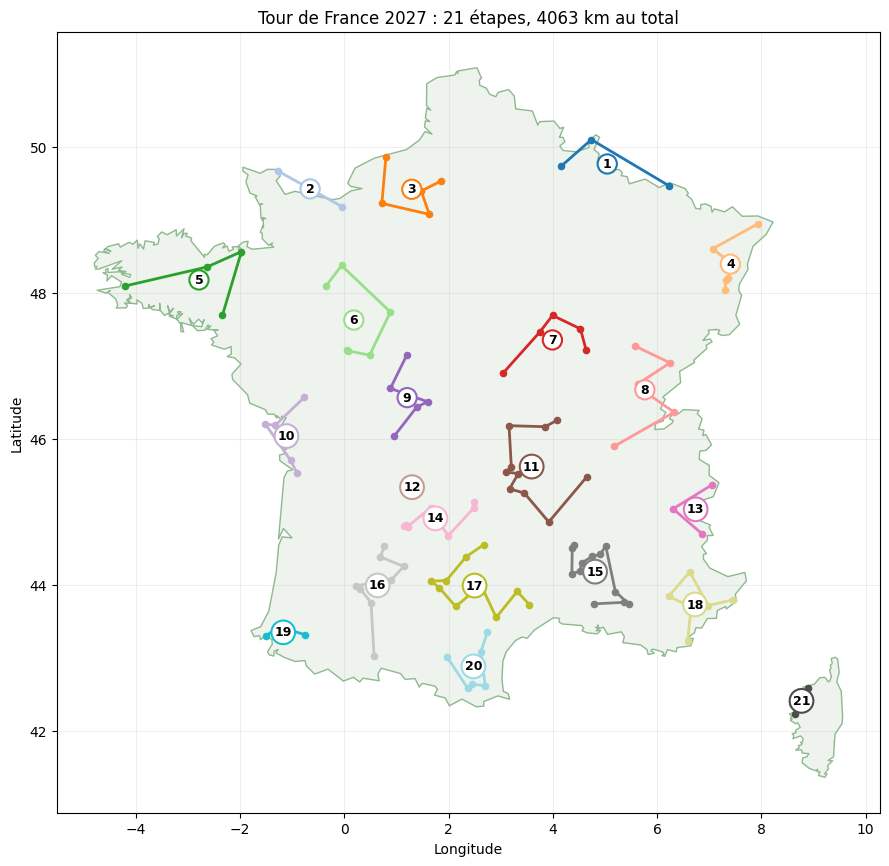

In [25]:
print_roadbook(villages, stage_paths, stage_distances)
plot_final_tour(villages, stage_paths, stage_distances)

### L'étape reine

Chaque Tour de France a son étape reine, la plus longue, la plus redoutée, celle dont on parle encore vingt ans après. Et la nôtre mérite qu'on la regarde de près : zoomons dessus, villages nommés, départ en or et arrivée en noir. Au passage, on affiche aussi le profil des 21 étapes pour voir le déséquilibre entre la plus courte et la plus longue :

Étape reine : l'étape 11, 362 km
La plus courte : l'étape 12, 19 km (presque un contre-la-montre !)


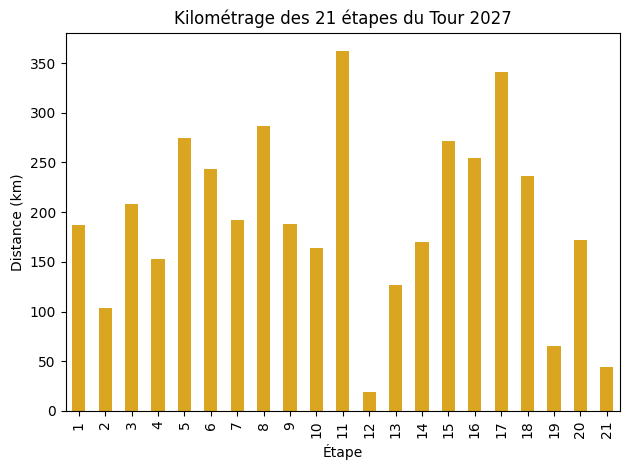

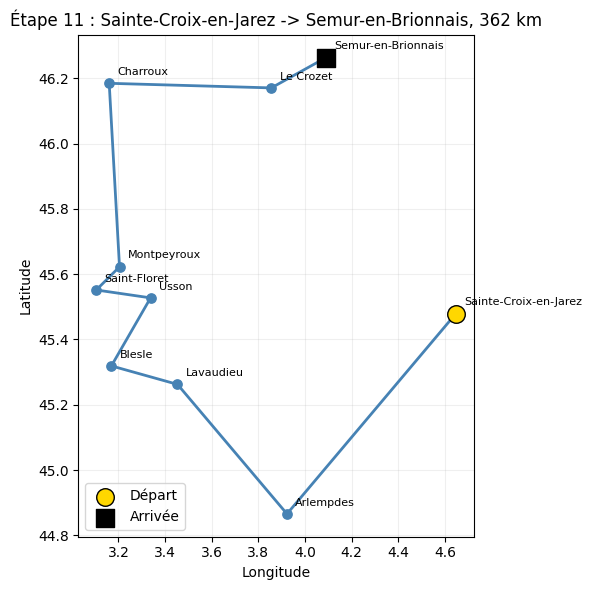

In [26]:
queen_stage = max(stage_distances, key=stage_distances.get)
sprint_stage = min(stage_distances, key=stage_distances.get)
print(f"Étape reine : l'étape {queen_stage}, {stage_distances[queen_stage]:.0f} km")
print(f"La plus courte : l'étape {sprint_stage}, {stage_distances[sprint_stage]:.0f} km (presque un contre-la-montre !)")

pd.Series(stage_distances).plot(kind="bar", color="goldenrod")
plt.title("Kilométrage des 21 étapes du Tour 2027")
plt.xlabel("Étape")
plt.ylabel("Distance (km)")
plt.tight_layout()
plt.show()

plot_stage_zoom(villages, stage_paths[queen_stage], queen_stage, stage_distances[queen_stage])


# Partie 5 : Analyse critique, d'où viennent les étapes trop longues ?

Le tracé fonctionne, mais un chiffre cloche : la moyenne des étapes s'établit autour de
193 km, alors qu'un vrai Tour de France tourne autour de 150 km. Neuf étapes sur vingt et
une dépassent 200 km, et l'étape reine atteint 362 km.

Deux explications possibles, et elles n'appellent pas la même réponse :

1. Le découpage est mauvais. Le K-Means produit des groupes déséquilibrés (de 2 à 12
   villages) ; les gros groupes seraient donc mécaniquement trop longs. → il faut changer
   d'algorithme.
2. La liste de villages ne s'y prête pas. Certaines zones sont denses, d'autres quasi
   vides. → aucun algorithme n'y changera rien, et c'est au comité qu'il faut le dire.

Plutôt que de choisir à l'intuition, testons.

### Hypothèse 1 : un clustering équilibré ferait mieux

Le K-Means classique minimise la distance au centre, sans aucune contrainte de taille. Il
existe une variante sous contrainte de capacité : on plafonne le nombre de villages par
groupe (ici 6, soit 120 ÷ 21 arrondi au supérieur) et on affecte chaque village à son centre
le plus proche encore disponible.

Si l'hypothèse 1 est la bonne, équilibrer les tailles devrait raccourcir les étapes.

In [27]:
import numpy as np


def kmeans_equilibre(features, n_clusters, cap=None, seed=42, n_iter=60):
    """K-Means sous contrainte de capacité : aucun groupe ne dépasse `cap` points.

    À chaque itération, les points sont affectés par ordre d'« hésitation » (ceux dont les
    deux centres les plus proches sont presque à égalité passent en premier), chacun rejoignant
    son centre le plus proche encore disponible. Les centres sont ensuite recalculés.
    """
    cap = cap or math.ceil(len(features) / n_clusters)
    centres = KMeans(n_clusters=n_clusters, random_state=seed,
                     n_init=10).fit(features).cluster_centers_

    for _ in range(n_iter):
        cout = np.linalg.norm(features[:, None, :] - centres[None, :, :], axis=2)
        hesitation = cout.min(1) - np.sort(cout, 1)[:, 1]      # plus c'est bas, plus c'est serré
        labels = -np.ones(len(features), int)
        remplissage = np.zeros(n_clusters, int)

        for i in np.argsort(hesitation):
            for c in np.argsort(cout[i]):
                if remplissage[c] < cap:
                    labels[i] = c
                    remplissage[c] += 1
                    break

        nouveaux = np.array([features[labels == c].mean(0) if (labels == c).any() else centres[c]
                             for c in range(n_clusters)])
        if np.allclose(nouveaux, centres):
            break
        centres = nouveaux

    return labels


def evaluer_decoupage(labels, nom):
    """Optimise chaque groupe (glouton + 2-opt, tous départs) et résume le tracé obtenu."""
    longueurs = []
    for k in sorted(set(labels)):
        indices = list(villages.index[labels == k])
        if len(indices) < 2:
            longueurs.append(0.0)
            continue
        meilleure = min(path_distance(two_opt(greedy_path(indices, s))) for s in indices)
        longueurs.append(meilleure)

    longueurs = pd.Series(longueurs)
    tailles = pd.Series(labels).value_counts()
    print(f"{nom:<28} total {longueurs.sum():6.0f} km | max {longueurs.max():4.0f} km | "
          f"> 200 km : {(longueurs > 200).sum():2d}/21 | tailles {tailles.min()}-{tailles.max()} | "
          f"silhouette {silhouette_score(features, labels):.3f}")
    return longueurs


F = villages[["x_km", "y_km"]].values

print("Comparaison des trois découpages :\n")
_ = evaluer_decoupage(labels_kmeans, "K-Means (retenu)")
_ = evaluer_decoupage(labels_cah, "CAH")
_ = evaluer_decoupage(kmeans_equilibre(F, N_STAGES), "K-Means équilibré (cap 6)")

Comparaison des trois découpages :

K-Means (retenu)             total   4063 km | max  362 km | > 200 km :  9/21 | tailles 2-12 | silhouette 0.461
CAH                          total   3930 km | max  324 km | > 200 km :  9/21 | tailles 1-14 | silhouette 0.467
K-Means équilibré (cap 6)    total   4820 km | max  454 km | > 200 km : 12/21 | tailles 3-6 | silhouette 0.339


L'hypothèse 1 est réfutée. Équilibrer les tailles rend le tracé 19 % plus long
(4 820 km contre 4 063), aggrave l'étape la plus longue (454 km contre 362) et fait passer
de neuf à douze le nombre d'étapes au-dessus de 200 km. La silhouette chute au passage.

La raison est géométrique. Forcer six villages par étape oblige à rattacher des villages
éloignés à des groupes déjà pleins ailleurs. On échange de la compacité contre de
l'équilibre, et pour ce problème, la compacité est ce qui compte.

C'est un résultat négatif, et il valait la peine d'être mesuré : sans le test, « il suffirait
d'équilibrer les groupes » serait resté une intuition plausible et fausse.

### Hypothèse 2 : c'est la liste de villages qui pose problème

Si le découpage n'est pas en cause, regardons la matière première. Un tracé court suppose des
villages proches les uns des autres. Mesurons la densité réelle.

Distance au village le plus proche :
  médiane : 26 km
  maximum : 120 km (Locronan)
  villages à plus de 50 km de tout voisin : 29/120

99 liaisons composent le tracé.
  les 10 plus longues pèsent 981 km, soit 24 % du total
  liaison la plus longue : 129 km


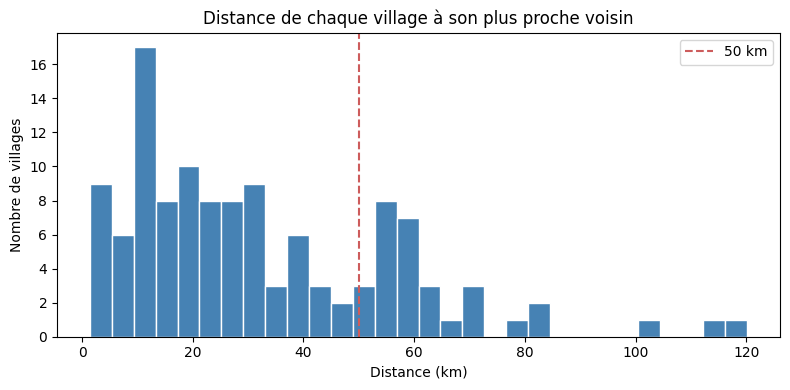

In [28]:
matrice = np.array(distances, dtype=float)
np.fill_diagonal(matrice, np.inf)
plus_proche = matrice.min(axis=1)

print(f"Distance au village le plus proche :")
print(f"  médiane : {np.median(plus_proche):.0f} km")
print(f"  maximum : {plus_proche.max():.0f} km ({villages['village'][plus_proche.argmax()]})")
print(f"  villages à plus de 50 km de tout voisin : {(plus_proche > 50).sum()}/120")

liaisons = []
for etape, chemin in stage_paths.items():
    liaisons += [distances[chemin[i]][chemin[i + 1]] for i in range(len(chemin) - 1)]
liaisons = np.array(sorted(liaisons, reverse=True))

print(f"\n{len(liaisons)} liaisons composent le tracé.")
print(f"  les 10 plus longues pèsent {liaisons[:10].sum():.0f} km, "
      f"soit {100 * liaisons[:10].sum() / liaisons.sum():.0f} % du total")
print(f"  liaison la plus longue : {liaisons[0]:.0f} km")

plt.figure(figsize=(8, 4))
plt.hist(plus_proche, bins=30, color="steelblue", edgecolor="white")
plt.axvline(50, color="indianred", linestyle="--", label="50 km")
plt.title("Distance de chaque village à son plus proche voisin")
plt.xlabel("Distance (km)")
plt.ylabel("Nombre de villages")
plt.legend()
plt.tight_layout()
plt.show()

L'hypothèse 2 est confirmée Vingt-neuf villages sur cent vingt près d'un quart se
trouvent à plus de 50 km de leur plus proche voisin. Locronan, en Bretagne, est à 120 km du
village le plus proche de la liste.

Ces isolés ne peuvent être rattachés à aucun groupe sans allonger le trajet, quel que soit
l'algorithme. Et l'effet est concentré : les dix liaisons les plus longues représentent à elles
seules près d'un quart du kilométrage total.

Le problème n'est pas dans le découpage. Il est dans la sélection des villages.

### Combien d'étapes faudrait-il pour tenir les 150 km ?

Dernière question, celle qui rend la recommandation actionnable. Si la liste reste inchangée,
quel nombre d'étapes permettrait d'atteindre la moyenne d'un vrai Tour ?

  21 étapes -> total  4063 km | moyenne 193 km | max  362 km
  25 étapes -> total  3684 km | moyenne 147 km | max  289 km
  30 étapes -> total  3206 km | moyenne 107 km | max  236 km
  35 étapes -> total  2856 km | moyenne  82 km | max  170 km
  40 étapes -> total  2532 km | moyenne  63 km | max  186 km


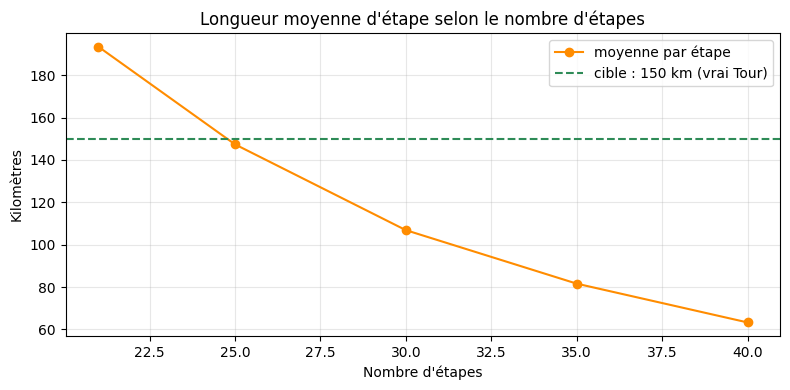

In [29]:
resultats = []
for n in (21, 25, 30, 35, 40):
    labels = KMeans(n_clusters=n, random_state=42, n_init=10).fit_predict(F)
    longueurs = []
    for k in sorted(set(labels)):
        indices = list(villages.index[labels == k])
        longueurs.append(
            min(path_distance(two_opt(greedy_path(indices, s))) for s in indices)
            if len(indices) > 1 else 0.0
        )
    longueurs = np.array(longueurs)
    resultats.append((n, longueurs.sum(), longueurs.mean(), longueurs.max()))
    print(f"  {n} étapes -> total {longueurs.sum():5.0f} km | "
          f"moyenne {longueurs.mean():3.0f} km | max {longueurs.max():4.0f} km")

ns, totaux, moyennes, maxima = zip(*resultats)
plt.figure(figsize=(8, 4))
plt.plot(ns, moyennes, marker="o", color="darkorange", label="moyenne par étape")
plt.axhline(150, color="seagreen", linestyle="--", label="cible : 150 km (vrai Tour)")
plt.title("Longueur moyenne d'étape selon le nombre d'étapes")
plt.xlabel("Nombre d'étapes")
plt.ylabel("Kilomètres")
plt.legend()
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

Il faudrait environ 25 étapes pour ramener la moyenne sous 150 km mais le Tour en compte
21, c'est une contrainte non négociable.

Autrement dit : les 120 villages proposés sont trop dispersés pour tenir en 21 étapes de
gabarit réaliste. Ce n'est pas un problème d'algorithme, c'est un problème de cahier des
charges.

## Conclusion et recommandation au comité

Le tracé livré : 21 étapes, 4 063 km, contre 46 789 km pour l'ordre alphabétique du
fichier. Le découpage par clustering ramène un problème à 199 chiffres de possibilités à
21 sous-problèmes de quelques villages, résolus quasi optimalement.

Le point de méthode : le K-Means a été préféré à la CAH *malgré* une silhouette
légèrement inférieure, parce que la CAH produisait une étape à un seul village. La métrique
ne connaissait pas la contrainte métier.

La recommandation : la liste de villages doit être révisée avant d'aller plus loin.

- Un quart des villages sont à plus de 50 km de tout voisin, et les dix liaisons les plus
  longues portent le quart du kilométrage.
- Équilibrer les tailles d'étapes ne corrige rien : testé, cela allonge le tracé de 19 %.
- Tenir la moyenne de 150 km demanderait 25 étapes, alors que le format en impose 21.

Trois pistes concrètes : densifier les zones creuses (Bretagne, Massif central) en ajoutant des
villages intermédiaires, retirer les isolés les plus coûteux, et détail non négligeable
prévoir une arrivée à Paris, absente de la liste actuelle.

Limites de l'analyse. Les distances sont à vol d'oiseau : le kilométrage routier réel sera
sensiblement supérieur, et le relief n'est pas modélisé alors qu'il structure un vrai Tour.
Le 2-opt garantit un optimum local, pas global sur des étapes de cette taille l'écart est
probablement négligeable, mais il n'est pas nul. Enfin, les transferts entre l'arrivée d'une
étape et le départ de la suivante ne sont pas comptés.

Pour aller plus loin : intégrer les distances routières via une API d'itinéraires, pondérer
par le dénivelé, ou traiter le problème comme un découpage sous contrainte de longueur plutôt
que de nombre d'étapes.